In [1]:
import pandas as pd
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

url = URL.create(
    drivername="mysql+pymysql",
    username="root",
    password="Sumit@2907",
    host="localhost",
    port=3306,
    database="olist_ecommerce"
)
engine = create_engine(url)

orders = pd.read_sql("SELECT * FROM olist_orders_dataset", engine)
order_items = pd.read_sql("SELECT * FROM olist_order_items_dataset", engine)
customers = pd.read_sql("SELECT * FROM olist_customers_dataset", engine)
sellers = pd.read_sql("SELECT * FROM olist_sellers_dataset", engine)
reviews = pd.read_sql("SELECT * FROM olist_order_reviews_dataset", engine)
payments = pd.read_sql("SELECT * FROM olist_order_payments_dataset", engine)
products = pd.read_sql("SELECT * FROM olist_products_dataset", engine)

print(orders.shape, order_items.shape, customers.shape, sellers.shape, reviews.shape, products.shape)

(99441, 8) (112650, 7) (99441, 5) (3095, 4) (99224, 7) (32951, 9)


In [2]:
df = orders.merge(order_items, on='order_id', how='inner')

In [3]:
df = df.merge(products, on='product_id', how='left')
df = df.merge(sellers, on='seller_id', how='left')
df = df.merge(customers, on='customer_id', how='left')

In [4]:
df = df[df['order_status'] == 'delivered'].copy()

In [5]:
print(df.shape)
df.head()

(110197, 29)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,1,4244733e06e7ecb4970a6e2683c13e61,...,28.0,9.0,14.0,27277,volta redonda,SP,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,1,e5f2d52b802189ee658865ca93d83a8f,...,50.0,30.0,40.0,3471,sao paulo,SP,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,1,c777355d18b72b67abbeef9df44fd0fd,...,33.0,13.0,33.0,37564,borda da mata,MG,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,1,7634da152a4610f1595efa32f14722fc,...,16.0,10.0,15.0,14403,franca,SP,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,1,ac6c3623068f30de03045865e4e10089,...,35.0,40.0,30.0,87900,loanda,PR,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP


In [6]:
df['is_late'] = (df['order_delivered_customer_date'] > df['order_estimated_delivery_date']).astype(int)
df['delivery_delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days

print(df['is_late'].value_counts(normalize=True))

is_late
0    0.920923
1    0.079077
Name: proportion, dtype: float64


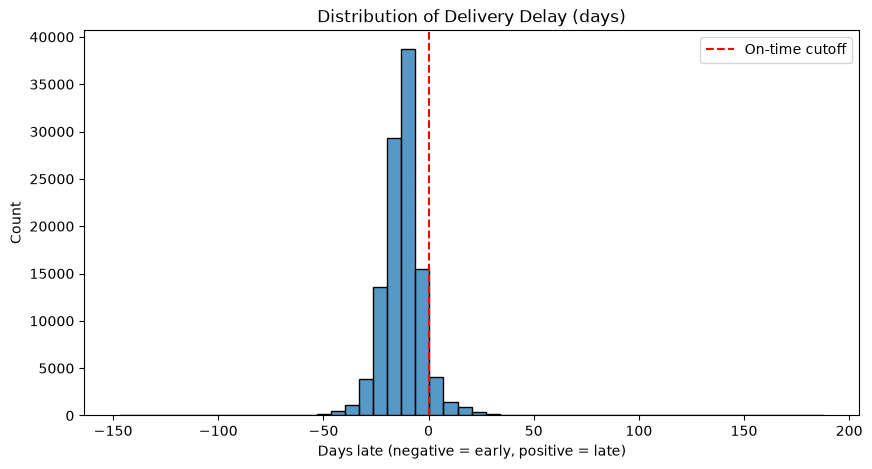

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(df['delivery_delay_days'], bins=50)
plt.axvline(0, color='red', linestyle='--', label='On-time cutoff')
plt.title('Distribution of Delivery Delay (days)')
plt.xlabel('Days late (negative = early, positive = late)')
plt.legend()
plt.show()

In [8]:
from scipy import stats

merged = df.merge(reviews, on='order_id')
on_time_scores = merged[merged['is_late'] == 0]['review_score']
late_scores = merged[merged['is_late'] == 1]['review_score']

print("On-time avg review score:", round(on_time_scores.mean(), 3))
print("Late avg review score:", round(late_scores.mean(), 3))
print("Sample sizes — on-time:", len(on_time_scores), "| late:", len(late_scores))

t_stat, p_value = stats.ttest_ind(on_time_scores, late_scores, equal_var=False)
print(f"T-statistic: {t_stat:.2f}, P-value: {p_value:.10f}")

On-time avg review score: 4.211
Late avg review score: 2.549
Sample sizes — on-time: 101453 | late: 8560
T-statistic: 90.50, P-value: 0.0000000000


In [9]:
import sys
print(sys.executable)

c:\Users\sumit\olist_ecommerce\.venv\Scripts\python.exe


In [10]:
category_summary = df.merge(
    products[['product_id', 'product_category_name']], 
    on='product_id', how='left', suffixes=('', '_dup')
)

cat_revenue = category_summary.groupby('product_category_name').agg(
    total_revenue=('price', 'sum'),
    order_count=('order_id', 'nunique'),
    avg_delay=('delivery_delay_days', 'mean')
).sort_values('total_revenue', ascending=False).head(10)

print(cat_revenue)

                        total_revenue  order_count  avg_delay
product_category_name                                        
beleza_saude               1233131.72         8647 -11.969149
relogios_presentes         1166176.98         5495 -11.920437
cama_mesa_banho            1023434.76         9272 -11.656167
esporte_lazer               954852.55         7530 -12.009490
informatica_acessorios      888724.61         6530 -12.419861
moveis_decoracao            711927.69         6307 -12.399510
utilidades_domesticas       615628.69         5743 -12.300221
cool_stuff                  610204.10         3559 -12.492469
automotivo                  578966.65         3810 -11.437062
brinquedos                  471286.48         3804 -12.095805


In [11]:
cat_revenue = df.groupby('product_category_name').agg(
    total_revenue=('price', 'sum'),
    order_count=('order_id', 'nunique'),
    avg_delay=('delivery_delay_days', 'mean')
).sort_values('total_revenue', ascending=False).head(10)

print(cat_revenue)

                        total_revenue  order_count  avg_delay
product_category_name                                        
beleza_saude               1233131.72         8647 -11.969149
relogios_presentes         1166176.98         5495 -11.920437
cama_mesa_banho            1023434.76         9272 -11.656167
esporte_lazer               954852.55         7530 -12.009490
informatica_acessorios      888724.61         6530 -12.419861
moveis_decoracao            711927.69         6307 -12.399510
utilidades_domesticas       615628.69         5743 -12.300221
cool_stuff                  610204.10         3559 -12.492469
automotivo                  578966.65         3810 -11.437062
brinquedos                  471286.48         3804 -12.095805


In [12]:
import os
from groq import Groq

client = Groq(api_key=os.environ.get("GROQ_API_KEY"))

# Feed it your ACTUAL validated findings — not raw data, the conclusions you already proved
business_findings = """
REVENUE OVERVIEW:
- Total revenue (delivered orders only): R$13,221,498.11
- Monthly growth stabilized post-Jan 2017 (pilot phase excluded), ranging -13% to +52% month-over-month
- Total sellers: 3,095

SELLER PERFORMANCE:
- 41% of total revenue is concentrated in sellers flagged "High Revenue - At Risk" 
  (top-quartile revenue but weak reviews or poor on-time delivery)

CUSTOMER SEGMENTATION (RFM):
- 39% of customers fall into "At Risk" or "Lost" segments
- Champions: 5,713 customers | Lost: 9,125 customers (out of 27,741 total)

DELIVERY & SATISFACTION:
- 7.9% of delivered orders arrive later than the estimated date
- On-time orders average 4.21/5 stars vs 2.55/5 for late orders (statistically significant, p<0.0001, n=110,013)
- Actual delivery averages ~12 days earlier than estimated date across all top product categories,
  suggesting delivery estimates are conservatively padded

TOP REVENUE CATEGORIES:
- beleza_saude (Health & Beauty): R$1,233,131.72
- relogios_presentes (Watches & Gifts): R$1,166,176.98
- cama_mesa_banho (Bed, Bath & Table): R$1,023,434.76
"""

prompt = f"""You are a senior business analyst presenting findings to Olist's leadership team.

Based STRICTLY on the data below, write a concise executive summary (300-400 words) with:
1. A 2-3 sentence overview of business health
2. Three key risks the business should address, ranked by urgency
3. Three specific, actionable recommendations tied directly to the data

Do not invent any numbers not present in the data below. If you're unsure of something, don't state it as fact.

DATA:
{business_findings}
"""

response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[{"role": "user", "content": prompt}],
    temperature=0.3,  # lower = more focused/less creative, appropriate for a factual business report
)

summary = response.choices[0].message.content
print(summary)

**Executive Summary**

Olist's business health is characterized by stabilized monthly growth and a sizable revenue base of R$13,221,498.11, with 3,095 active sellers contributing to this figure. However, this growth is accompanied by notable risks that require attention. The company's revenue trajectory is marked by fluctuations, ranging from -13% to +52% month-over-month, indicating a need for strategies to mitigate volatility.

The three key risks the business should address, ranked by urgency, are:
1. **Concentration of revenue in "High Revenue - At Risk" sellers**: 41% of total revenue is generated by sellers with weak reviews or poor on-time delivery, posing a significant threat to long-term sustainability.
2. **Customer churn**: 39% of customers are categorized as "At Risk" or "Lost", highlighting the need for targeted retention strategies to prevent further erosion of the customer base.
3. **Delivery satisfaction**: 7.9% of delivered orders arrive later than estimated, resulting

In [14]:
import os

os.makedirs('docs', exist_ok=True)

with open('docs/executive_summary_ai_generated.md', 'w', encoding='utf-8') as f:
    f.write("# Olist E-Commerce — AI-Generated Executive Summary\n\n")
    f.write(f"*Generated using Groq (llama-3.3-70b-versatile) from validated SQL/Excel/Python findings*\n\n")
    f.write(summary)

print("Saved to:", os.path.abspath('docs/executive_summary_ai_generated.md'))

Saved to: c:\Users\sumit\olist_ecommerce\docs\executive_summary_ai_generated.md
